<a href="https://colab.research.google.com/github/stecorrea1313/laboratorios/blob/main/case_ifood_stephanie.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#Instalando as bibliotecas necessárias
!pip install pyspark
!pip install scipy

In [ ]:
# Importando as bibliotecas necessárias
from pyspark.sql import SparkSession
import tarfile
import os
from pyspark.sql import functions as F
import pandas as pd
from scipy.stats import ttest_ind
import matplotlib.pyplot as plt
import numpy as np
from pyspark.sql.functions import col, count, sum, avg, min, max, datediff, when, to_date, current_date, lit, last, col, udf, countDistinct
from pyspark.sql.types import StringType


In [ ]:
# Inicializando a Spark Session
spark = SparkSession.builder \
    .appName("Case Ifood") \
    .getOrCreate()

# Baixando os arquivos usando wget
!wget https://data-architect-test-source.s3-sa-east-1.amazonaws.com/order.json.gz
!wget https://data-architect-test-source.s3-sa-east-1.amazonaws.com/consumer.csv.gz
!wget https://data-architect-test-source.s3-sa-east-1.amazonaws.com/restaurant.csv.gz
!wget https://data-architect-test-source.s3-sa-east-1.amazonaws.com/ab_test_ref.tar.gz

# Lendo os arquivos CSV e JSON
df_consumer = spark.read.csv('consumer.csv.gz', header=True, inferSchema=True)
df_restaurant = spark.read.csv('restaurant.csv.gz', header=True, inferSchema=True)
df_order = spark.read.json('order.json.gz')

# Extraindo o arquivo .tar.gz
with tarfile.open('ab_test_ref.tar.gz', 'r:gz') as tar:
    tar.extractall()  # Extrai para o diretório atual
extracted_files = os.listdir('.')

# Verificando o conteúdo dos arquivos extraídos
for file in extracted_files:
    if os.path.isfile(file):  # Verificando se é um arquivo, não um diretório
        print(f"Verificando conteúdo do arquivo: {file}")
        with open(file, 'r', encoding='ISO-8859-1') as f:
            print(f.read(200))  # Exibindo as primeiras 200 linhas para verificação
    else:
        print(f"{file} é um diretório e foi ignorado.")

# Carregando o arquivo ab_test_ref.csv (marcação do teste A/B)
ab_test_file = 'ab_test_ref.csv'
df_ab_test = spark.read.csv(ab_test_file, header=True, inferSchema=True)


--2025-04-14 00:05:31--  https://data-architect-test-source.s3-sa-east-1.amazonaws.com/order.json.gz
Resolving data-architect-test-source.s3-sa-east-1.amazonaws.com (data-architect-test-source.s3-sa-east-1.amazonaws.com)... 3.5.233.194, 3.5.233.125, 52.95.164.23, ...
Connecting to data-architect-test-source.s3-sa-east-1.amazonaws.com (data-architect-test-source.s3-sa-east-1.amazonaws.com)|3.5.233.194|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1610800545 (1.5G) [application/json]
Saving to: ‘order.json.gz.10’

order.json.gz.10    100%[===================>]   1.50G  17.7MB/s    in 93s     

2025-04-14 00:07:05 (16.5 MB/s) - ‘order.json.gz.10’ saved [1610800545/1610800545]

--2025-04-14 00:07:05--  https://data-architect-test-source.s3-sa-east-1.amazonaws.com/consumer.csv.gz
Resolving data-architect-test-source.s3-sa-east-1.amazonaws.com (data-architect-test-source.s3-sa-east-1.amazonaws.com)... 3.5.232.136, 3.5.233.190, 3.5.233.153, ...
Connecting to data-a

In [ ]:
# Checando se há customer_id nulo na base principal do A/B
df_ab_test.filter(col("customer_id").isNull()).count()

# 1. Unindo todas as bases a partir da ab_test
df_ab = df_ab_test.alias("ab")

df_ab_orders = df_ab.join(df_order.alias("ord"), col("ab.customer_id") == col("ord.customer_id"), "left") \
                    .join(df_consumer.alias("con"), col("ab.customer_id") == col("con.customer_id"), "left") \
                    .join(df_restaurant.alias("res"), col("ord.merchant_id") == col("res.id"), "left")

# 2. Convertendo data de pedido para o tipo apenas data
df_ab_orders = df_ab_orders.withColumn("order_date", to_date("ord.order_created_at"))

# 3. Agregando as métricas que serão analisadas por usuário
df_user_metrics = df_ab_orders.groupBy("ab.customer_id", "ab.is_target","con.created_at").agg(
    count("ord.order_id").alias("num_pedidos"),
    sum("ord.order_total_amount").alias("valor_total"),
    avg("ord.order_total_amount").alias("ticket_medio"),
    min("order_date").alias("primeiro_pedido"),
    max("order_date").alias("ultimo_pedido"),
    last("delivery_address_state").alias("delivery_address_state")
)

# 4. Calculando média de dias entre pedidos
df_user_metrics = df_user_metrics.withColumn(
    "dias_entre_pedidos",
    datediff("ultimo_pedido", "primeiro_pedido") / F.when(col("num_pedidos") > 1, col("num_pedidos") - 1).otherwise(1)
)

#**1a) Indicadores Relevantes e impacto do teste A/B**

**Indicadores que serão analisados:**

1. Número de pedidos por usuário (num_pedidos)

2. Valor total gasto por usuário (valor_total)

3. Ticket médio (ticket_medio)

4. Média de dias entre pedidos (dias_entre_pedidos)

**Análise estatística para verificar impacto:** Comparar os grupos target e control para ver se as diferenças são estatisticamente significativas com teste t.


In [ ]:
# Estatísticas por grupo
df_user_metrics.groupBy("is_target").agg(
    F.avg("num_pedidos").alias("avg_num_pedidos"),
    F.avg("valor_total").alias("avg_valor_total"),
    F.avg("ticket_medio").alias("avg_ticket_medio"),
    F.avg("dias_entre_pedidos").alias("avg_dias_entre_pedidos")
).show()

# Convertendo para Pandas
df_user_pd = df_user_metrics.toPandas()

# Separando os grupos
grupo_target = df_user_pd[df_user_pd["is_target"] == "target"]
grupo_control = df_user_pd[df_user_pd["is_target"] == "control"]

# Função de teste t
def teste_t(metrica):
    stat, pval = ttest_ind(grupo_target[metrica].dropna(), grupo_control[metrica].dropna(), equal_var=False)
    print(f"\nTeste t para {metrica}:")
    print(f"Estatística t: {stat:.4f}, p-valor: {pval:.4f}")
    if pval < 0.05:
        print("➡️ Diferença significativa entre os grupos.")
    else:
        print("➡️ Não há diferença significativa entre os grupos.")

# Rodando os testes
for metrica in ["num_pedidos", "valor_total", "ticket_medio", "dias_entre_pedidos"]:
    teste_t(metrica)


+---------+-----------------+------------------+-----------------+----------------------+
|is_target|  avg_num_pedidos|   avg_valor_total| avg_ticket_medio|avg_dias_entre_pedidos|
+---------+-----------------+------------------+-----------------+----------------------+
|  control|4.231340592774212|202.67229027408288|48.01138187777102|    12.500832154016692|
|   target|4.791713853226439|228.75550506364186|47.83360779327981|     11.87106578986403|
+---------+-----------------+------------------+-----------------+----------------------+


Teste t para num_pedidos:
Estatística t: 44.2495, p-valor: 0.0000
➡️ Diferença significativa entre os grupos.

Teste t para valor_total:
Estatística t: 24.3133, p-valor: 0.0000
➡️ Diferença significativa entre os grupos.

Teste t para ticket_medio:
Estatística t: -0.8081, p-valor: 0.4190
➡️ Não há diferença significativa entre os grupos.

Teste t para dias_entre_pedidos:
Estatística t: -24.3569, p-valor: 0.0000
➡️ Diferença significativa entre os grupos.

**Conclusões:**

🔹 Médias por grupo:
- Control:
  • Número de pedidos: 4.23
  • Valor total: 202.67
  • Ticket médio: 48.01
  • Dias entre pedidos: 12.50

- Target:
  • Número de pedidos: 4.79
  • Valor total: 228.76
  • Ticket médio: 47.83
  • Dias entre pedidos: 11.87

🔹 Testes t de significância:

- Número de pedidos:
  • t = 44.25
  • p-valor = 0.0000 ✅ ➝ Diferença significativa

- Valor total gasto:
  • t = 24.31
  • p-valor = 0.0000 ✅ ➝ Diferença significativa

- Ticket médio:
  • t = -0.81
  • p-valor = 0.4190 ❌ ➝ Diferença NÃO significativa

- Dias entre pedidos:
  • t = -24.36
  • p-valor = 0.0000 ✅ ➝ Diferença significativa

**O cupom gerou aumento significativo no número de pedidos e no valor total gasto por usuário. Apesar disso, o ticket médio permaneceu praticamente igual, o que indica que o aumento de receita veio do aumento na frequência de pedidos.**



# **1b) Viabilidade Financeira**



**Premissas:**
- A campanha de cupons foi disponibilizada apenas para o grupo Target.
- O valor do cupom foi de R$15 por usuário (desconto único por CPF/usuário).
- Nem todos os usuários do grupo Target usaram o cupom. - Assumindo que 60% dos usuários utilizaram.
- O grupo Target inteiro foi exposto à campanha, então toda a diferença de comportamento (em relação ao grupo Controle) pode ser atribuída ao impacto do cupom — seja via incentivo direto ou indireto.

- A receita incremental deve considerar todos os usuários do grupo Target, comparando o gasto médio com o grupo Controle.

- O custo da campanha só se aplica aos usuários que de fato usaram o cupom — então precisamos multiplicar valor do cupom × usuários que usaram.

- A viabilidade será medida comparando o custo total estimado dos cupons com a receita incremental estimada.

In [ ]:
# 1. Contando usuários por grupo
usuarios_por_grupo = df_user_metrics.groupBy("is_target").count().toPandas()
num_usuarios_target = usuarios_por_grupo.loc[usuarios_por_grupo["is_target"] == "target", "count"].values[0]
num_usuarios_control = usuarios_por_grupo.loc[usuarios_por_grupo["is_target"] == "control", "count"].values[0]

# 2. Calculando o gasto médio por grupo
metricas_medias = df_user_metrics.groupBy("is_target").agg(
    F.avg("valor_total").alias("avg_valor_total")
).toPandas()

avg_valor_target = metricas_medias.loc[metricas_medias["is_target"] == "target", "avg_valor_total"].values[0]
avg_valor_control = metricas_medias.loc[metricas_medias["is_target"] == "control", "avg_valor_total"].values[0]

# 3. Premissas
valor_cupom = 15
taxa_uso_cupom = 0.60  # Premissa: 60% dos usuários do grupo target usaram o cupom

# 4. Receita incremental total (todo o grupo target)
receita_incremental_total = (avg_valor_target - avg_valor_control) * num_usuarios_target

# 5. Custo total da campanha (somente usuários que usaram cupom)
num_usuarios_usaram = taxa_uso_cupom * num_usuarios_target
custo_total_campanha = valor_cupom * num_usuarios_usaram

# 6. ROI da campanha
roi = (receita_incremental_total - custo_total_campanha) / custo_total_campanha

# 7. Exibindo os resultados
print(f"Número de usuários no grupo Target: {num_usuarios_target}")
print(f"Valor médio total - Target: R${avg_valor_target:.2f}")
print(f"Valor médio total - Control: R${avg_valor_control:.2f}")
print(f"Receita incremental total: R${receita_incremental_total:,.2f}")
print(f"Custo total da campanha: R${custo_total_campanha:,.2f}")
print(f"ROI da campanha: {roi:.2f}")


Número de usuários no grupo Target: 445925
Valor médio total - Target: R$228.76
Valor médio total - Control: R$202.67
Receita incremental total: R$11,631,157.56
Custo total da campanha: R$4,013,325.00
ROI da campanha: 1.90


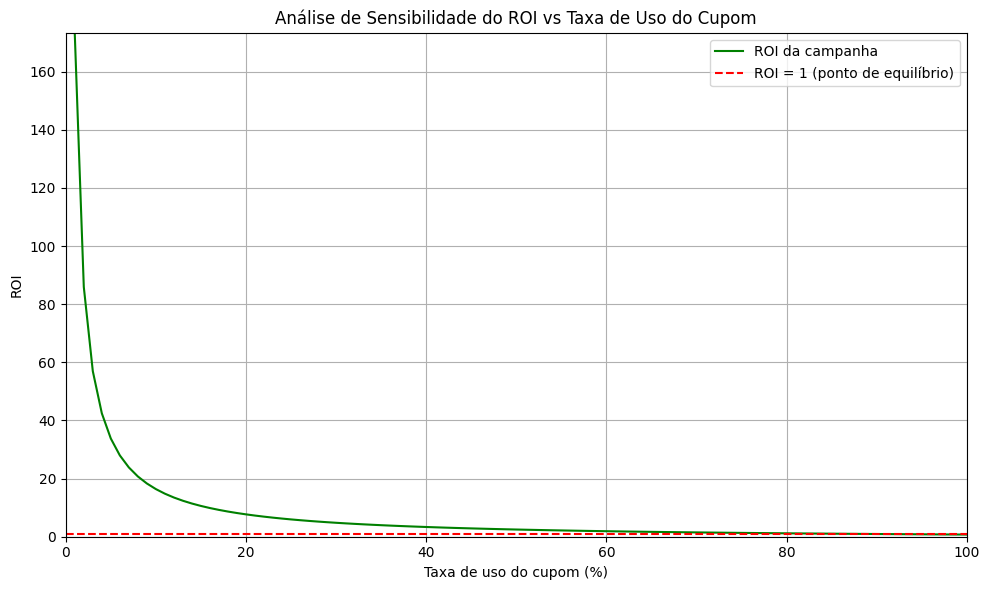

In [ ]:
# Curva de ROI com base na taxa de uso do cupom
taxas_uso = np.linspace(0.01, 1.00, 100)
num_usuarios_usaram = taxas_uso * num_usuarios_target
custos = num_usuarios_usaram * valor_cupom
rois = (receita_incremental_total - custos) / custos

# Gráfico
plt.figure(figsize=(10, 6))
plt.plot(taxas_uso * 100, rois, label='ROI da campanha', color='green')
plt.axhline(1, linestyle='--', color='red', label='ROI = 1 (ponto de equilíbrio)')
plt.xlabel('Taxa de uso do cupom (%)')
plt.ylabel('ROI')
plt.title('Análise de Sensibilidade do ROI vs Taxa de Uso do Cupom')
plt.grid(True)
plt.legend()
plt.xlim(0, 100)
plt.ylim(0, np.max(rois) + 0.5)  # <-- corrigido aqui
plt.tight_layout()
plt.show()


**Conclusões:**
- A campanha gerou um aumento médio de 26,09 por usuário no grupo Target em relação ao grupo Controle.

- Considerando que 60% dos usuários Target usaram o cupom, e que cada uso custou R$15 ao Ifood, o custo estimado da campanha foi de 4 milhões

- A receita incremental total foi de mais de 11 milhões, resultando em um ROI de 1,90, ou seja: para cada R$1 gasto com cupons, houve um retorno de 1,90 em receita adicional.

- Isso indica que, com as premissas adotadas, a campanha foi financeiramente viável.


**Sensibilidade**
- Além disso, como vimos no gráfico de sensibilidade, o ROI se mantém maior que 1 até aproximadamente 78% de taxa de uso dos cupons — o que dá uma margem segura para variações de comportamento dos usuários.

# **2a) e 2b) Definir Segmentações e Estabelecer critérios**

**Segmentações:**
- Frequência de pedidos (num_pedidos)
- Ticket Médio (ticket medio)
- Intervalo Médio entre pedidos (dias_entre_pedidos)
- Tempo na Plataforma (dias_na_plataforma)
- Região (delivery_address_state)

**Critérios:**
- Será feita a análise da distribuição dos dados para estabelecer os critérios com P25, P50 e P75

In [ ]:
df_user_metrics = df_user_metrics.withColumn(
    "dias_na_plataforma",
    datediff(lit("2020-01-01"), to_date("created_at"))
)

# 2. Converter para Pandas
df_pd = df_user_metrics.toPandas()

# 3. Lista de métricas a calcular os percentis
metricas = [
    "num_pedidos",
    "valor_total",
    "ticket_medio",
    "dias_entre_pedidos",
    "dias_na_plataforma"
]

# 4. Função para exibir os percentis
def mostrar_percentis(coluna):
    print(f"\n📊 {coluna}:")
    for p in [0.25, 0.5, 0.75]:
        val = df_pd[coluna].quantile(p)
        print(f"  P{int(p*100)}: {val:.2f}")

# 5. Aplicando para todas as métricas
for col_new in metricas:
    mostrar_percentis(col_new)



📊 num_pedidos:
  P25: 2.00
  P50: 2.00
  P75: 5.00

📊 valor_total:
  P25: 56.00
  P50: 111.60
  P75: 243.20

📊 ticket_medio:
  P25: 29.43
  P50: 40.90
  P75: 56.80

📊 dias_entre_pedidos:
  P25: 1.83
  P50: 8.50
  P75: 24.50

📊 dias_na_plataforma:
  P25: 636.00
  P50: 700.00
  P75: 724.00


In [ ]:
# 1. Join com df_consumer e cálculo de dias_na_plataforma (com alias para evitar ambiguidade)
df_user_metrics = df_user_metrics.join(
    df_consumer.select(
        col("customer_id"),
        col("created_at").alias("created_at_cons")
    ),
    on="customer_id",
    how="left"
).withColumn(
    "dias_na_plataforma",
    datediff(lit("2020-01-01"), to_date(col("created_at_cons")))
)

# 2. UDF para mapear estados para regiões do Brasil
def mapear_regiao(estado):
    if estado in ["SP", "RJ", "MG", "ES"]:
        return "Sudeste"
    elif estado in ["RS", "SC", "PR"]:
        return "Sul"
    elif estado in ["DF", "GO", "MT", "MS"]:
        return "Centro-Oeste"
    elif estado in ["BA", "PE", "CE", "RN", "MA", "PB", "AL", "SE", "PI"]:
        return "Nordeste"
    elif estado in ["AM", "PA", "RO", "RR", "TO", "AC", "AP"]:
        return "Norte"
    else:
        return "Outro"

udf_regiao = udf(mapear_regiao, StringType())
df_user_metrics = df_user_metrics.withColumn("regiao", udf_regiao(col("delivery_address_state")))

# 3. Segmentação: frequência de pedidos
df_user_metrics = df_user_metrics.withColumn(
    "segmento_frequencia",
    when(col("num_pedidos") <= 2, "Baixa")
    .when((col("num_pedidos") > 2) & (col("num_pedidos") <= 5), "Média")
    .otherwise("Alta")
)

# 4. Segmentação: ticket médio
df_user_metrics = df_user_metrics.withColumn(
    "segmento_ticket_medio",
    when(col("ticket_medio") <= 29.43, "Baixo")
    .when((col("ticket_medio") > 29.43) & (col("ticket_medio") <= 56.80), "Médio")
    .otherwise("Alto")
)

# 5. Segmentação: recência
df_user_metrics = df_user_metrics.withColumn(
    "segmento_recencia",
    when((col("num_pedidos") == 1) | (col("dias_entre_pedidos") > 24.5), "Inativo")
    .when((col("dias_entre_pedidos") > 1.83) & (col("dias_entre_pedidos") <= 24.5), "Moderado")
    .otherwise("Frequente")
)

# 6. Segmentação: tempo de plataforma
df_user_metrics = df_user_metrics.withColumn(
    "segmento_tempo_plataforma",
    when(col("dias_na_plataforma") <= 636, "Novo")
    .when((col("dias_na_plataforma") > 636) & (col("dias_na_plataforma") <= 724), "Médio tempo")
    .otherwise("Antigo")
)

# **2c) Análise do teste A/B com as segmentações**

Foi utilizada a mesma lógica do 1a para as segmentações descritas nos itens acima, além da utilização do teste p-valor para determinar a significância estatística.

In [ ]:
from pyspark.sql.functions import avg
from scipy.stats import ttest_ind

# 1. Converter para Pandas
df_pd = df_user_metrics.toPandas()

# 2. Lista de segmentos e métricas
segmentos = [
    "segmento_frequencia",
    "segmento_ticket_medio",
    "segmento_recencia",
    "segmento_tempo_plataforma",
    "regiao"
]

metricas = ["valor_total", "ticket_medio", "num_pedidos"]

# 3. Loop por segmento e métrica
for segmento in segmentos:
    print(f"\n📊 Análise por: {segmento.upper()}")

    # --- Parte A: análise descritiva
    df_user_metrics.groupBy(segmento, "is_target").agg(
        avg("valor_total").alias("avg_valor_total"),
        avg("ticket_medio").alias("avg_ticket_medio"),
        avg("num_pedidos").alias("avg_num_pedidos")
    ).orderBy(segmento, "is_target").show(truncate=False)

    # --- Parte B: testes t
    categorias = df_pd[segmento].dropna().unique()

    for categoria in categorias:
        grupo_segmento = df_pd[df_pd[segmento] == categoria]

        for metrica in metricas:
            target = grupo_segmento[grupo_segmento["is_target"] == "target"][metrica].dropna()
            control = grupo_segmento[grupo_segmento["is_target"] == "control"][metrica].dropna()

            if len(target) > 5 and len(control) > 5:
                t_stat, p_val = ttest_ind(target, control, equal_var=False)
                print(f"\n🔬 Teste t — Segmento: {segmento} = '{categoria}', Métrica = {metrica}")
                print(f"Target média:  {target.mean():.2f}")
                print(f"Control média: {control.mean():.2f}")
                print(f"t = {t_stat:.4f}, p-valor = {p_val:.4f}")

                if p_val < 0.05:
                    print("✅ Diferença estatisticamente significativa!")
                else:
                    print("⚠️ Diferença NÃO significativa.")



📊 Análise por: SEGMENTO_FREQUENCIA
+-------------------+---------+------------------+-----------------+------------------+
|segmento_frequencia|is_target|avg_valor_total   |avg_ticket_medio |avg_num_pedidos   |
+-------------------+---------+------------------+-----------------+------------------+
|Alta               |control  |559.3595563056375 |47.7809243929956 |11.736115226549517|
|Alta               |target   |560.4014501222435 |47.79604802914704|11.756610774912868|
|Baixa              |control  |74.33147892472016 |47.77971912533068|1.558496192555514 |
|Baixa              |target   |75.11406497122915 |47.74616918043648|1.5758883613868508|
|Média              |control  |187.28056226425045|48.87242917889079|3.83316743503772  |
|Média              |target   |184.04690674358466|48.03493783629619|3.8326006498583864|
+-------------------+---------+------------------+-----------------+------------------+


🔬 Teste t — Segmento: segmento_frequencia = 'Média', Métrica = valor_total
Target 

# **3) Apoio para a previsão de Impacto**

Quero calcular qual é a % de pessoas que tiveram impacto significativo na métrica "valor total" para usar na minha previsão de impacto - estou pegando as segmentações que tiveram maior impacto financeiro vs grupo controle

In [ ]:
# Novo filtro de responsivos com foco em ROI positivo
df_user_metrics = df_user_metrics.withColumn(
    "is_responsivo_roi",
    when(
        (col("regiao") == "Sudeste") &
        (col("segmento_ticket_medio").isin("Médio", "Alto")),
        1
    ).otherwise(0)
)

# Filtrar Target e Controle nos mesmos segmentos
df_target_roi = df_user_metrics.filter((col("is_target") == "target") & (col("is_responsivo_roi") == 1))
df_control_roi = df_user_metrics.filter((col("is_target") == "control") & (col("is_responsivo_roi") == 1))

# Contagem
n_roi = df_target_roi.count()

# Médias
avg_target_roi = df_target_roi.agg(avg("valor_total")).first()[0]
avg_control_roi = df_control_roi.agg(avg("valor_total")).first()[0]

# Delta, receita incremental, custo e ROI
delta = avg_target_roi - avg_control_roi
receita = delta * n_roi
custo = n_roi * 15 * 0.60
roi = (receita - custo) / custo

# Percentual no grupo Target
n_target_total = df_user_metrics.filter(col("is_target") == "target").count()
perc_roi = (n_roi / n_target_total) * 100

# Resultado
print(f"Usuários ROI-positivos (target): {n_roi} ({perc_roi:.2f}%)")
print(f"Valor médio - Target: R$ {avg_target_roi:.2f}")
print(f"Valor médio - Controle: R$ {avg_control_roi:.2f}")
print(f"Delta: R$ {delta:.2f}")
print(f"Receita incremental: R$ {receita:,.2f}")
print(f"Custo estimado: R$ {custo:,.2f}")
print(f"ROI estimado: {roi:.2f}")


Usuários ROI-positivos (target): 236249 (52.98%)
Valor médio - Target: R$ 284.70
Valor médio - Controle: R$ 251.52
Delta: R$ 33.19
Receita incremental: R$ 7,840,570.58
Custo estimado: R$ 2,126,241.00
ROI estimado: 2.69
